# T20I Batting Stats — Web Scraping & EDA

This project scrapes T20 International batting statistics from ESPNcricinfo, cleans the data, and performs exploratory data analysis (EDA) to identify top performers, power hitters, and consistency trends.

## 1. Imports

In [2]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams['figure.figsize'] = (10, 6)


## 2. Web Scraping

Scrape T20I batting stats from ESPNcricinfo across multiple pages and combine them into a single DataFrame.

In [3]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.espncricinfo.com/",
    "Connection": "keep-alive"
}

batting_df = []

for page in range(1, 11):
    url = f"https://stats.espncricinfo.com/ci/engine/stats/index.html?class=3;page={page};template=results;type=batting"

    try:
        response = requests.get(url, headers=headers)
        print(f"Page {page} status:", response.status_code)

        tables = pd.read_html(response.text)

        for table in tables:
            if "Player" in table.columns:
                batting_df.append(table)
                print(f"Page {page} scraped")
                break

        time.sleep(2)

    except Exception as e:
        print(f"Error in page {page}: {e}")

if batting_df:
    batting_df1 = pd.concat(batting_df, ignore_index=True)
    batting_df1.to_csv("t20i_batting_stat.csv", index=False)
    print("CSV saved")
    print("Shape:", batting_df1.shape)
    print(batting_df1.head())
else:
    print("No data found")


Page 1 status: 200
Page 1 scraped


C:\Users\nanda\AppData\Local\Temp\ipykernel_29560\522189454.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Page 2 status: 200
Page 2 scraped


C:\Users\nanda\AppData\Local\Temp\ipykernel_29560\522189454.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Page 3 status: 200
Page 3 scraped


...

Page 9 status: 200
Page 9 scraped


C:\Users\nanda\AppData\Local\Temp\ipykernel_29560\522189454.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Page 10 status: 200
Page 10 scraped


C:\Users\nanda\AppData\Local\Temp\ipykernel_29560\522189454.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


CSV saved
Shape: (500, 16)
              Player       Span  Mat  Inns  NO  Runs    HS    Ave    BF  \
0   Babar Azam (PAK)  2016-2026  145   136  18  4596   122  38.94  3590   
1    RG Sharma (IND)  2007-2024  159   151  19  4231  121*  32.05  3003   
2      V Kohli (IND)  2010-2024  125   117  31  4188  122*  48.69  3056   
3   JC Buttler (ENG)  2011-2026  157   144  23  4037  101*  33.36  2735   
4  PR Stirling (IRE)  2009-2026  163   160  12  3895  115*  26.31  2899   

       SR  100  50   0   4s   6s  Unnamed: 15  
0  128.02    3  39  10  477   80          NaN  
1  140.89    5  32  12  383  205          NaN  
2  137.04    1  38   7  369  124          NaN  
3  147.60    1  28  11  373  175          NaN  
4  134.35    1  24  14  449  141          NaN  


## 3. Data Cleaning

Drop any unnamed/blank columns that come from stray HTML table formatting on the source page.

In [4]:
# Drop any unnamed columns picked up from the HTML table (robust to column count changing between scrapes)
batting_df1 = batting_df1.loc[:, ~batting_df1.columns.str.contains('^Unnamed')]
batting_df1.head()


,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,4s,6s
0,Babar Azam (PAK),2016-2026,145,136,18,4596,122,38.94,3590,128.02,3,39,10,477,80
1,RG Sharma (IND),2007-2024,159,151,19,4231,121*,32.05,3003,140.89,5,32,12,383,205
2,V Kohli (IND),2010-2024,125,117,31,4188,122*,48.69,3056,137.04,1,38,7,369,124
3,JC Buttler (ENG),2011-2026,157,144,23,4037,101*,33.36,2735,147.60,1,28,11,373,175
4,PR Stirling (IRE),2009-2026,163,160,12,3895,115*,26.31,2899,134.35,1,24,14,449,141


## 4. Load & Explore the Data

From this point on, the analysis works off the saved CSV, so it can be re-run without repeating the scrape.

In [5]:
file_path = 't20i_batting_stat.csv'
df = pd.read_csv(file_path)
df.head()


,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,4s,6s,Unnamed: 15
0,Babar Azam (PAK),2016-2026,145,136,18,4596,122,38.94,3590,128.02,3,39,10,477,80,NaN
1,RG Sharma (IND),2007-2024,159,151,19,4231,121*,32.05,3003,140.89,5,32,12,383,205,NaN
2,V Kohli (IND),2010-2024,125,117,31,4188,122*,48.69,3056,137.04,1,38,7,369,124,NaN
3,JC Buttler (ENG),2011-2026,157,144,23,4037,101*,33.36,2735,147.60,1,28,11,373,175,NaN
4,PR Stirling (IRE),2009-2026,163,160,12,3895,115*,26.31,2899,134.35,1,24,14,449,141,NaN


In [6]:
df.shape


(500, 16)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player       500 non-null    object 
 1   Span         500 non-null    object 
 2   Mat          500 non-null    int64  
 3   Inns         500 non-null    int64  
 4   NO           500 non-null    int64  
 5   Runs         500 non-null    int64  
 6   HS           500 non-null    object 
 7   Ave          500 non-null    float64
 8   BF           500 non-null    int64  
 9   SR           500 non-null    float64
 10  100          500 non-null    int64  
 11  50           500 non-null    int64  
 12  0            500 non-null    int64  
 13  4s           500 non-null    int64  
 14  6s           500 non-null    int64  
 15  Unnamed: 15  0 non-null      float64
dtypes: float64(3), int64(10), object(3)
memory usage: 62.6+ KB


In [8]:
df.isnull().sum()


Player           0
Span             0
Mat              0
Inns             0
NO               0
Runs             0
HS               0
Ave              0
BF               0
SR               0
100              0
50               0
0                0
4s               0
6s               0
Unnamed: 15    500
dtype: int64

In [9]:
df.describe()


,Mat,Inns,NO,Runs,Ave,BF,SR,100,50,0,4s,6s,Unnamed: 15
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,0.0
mean,62.180000,56.128000,8.798000,1221.816000,25.992060,958.506000,127.225120,0.442000,6.192000,4.062000,105.792000,49.080000,NaN
std,28.329361,24.879582,6.892911,675.369785,6.841783,492.641132,17.476015,0.812377,5.458087,2.893943,65.756403,34.034251,NaN
min,17.000000,17.000000,0.000000,577.000000,8.980000,367.000000,77.450000,0.000000,0.000000,0.000000,27.000000,1.000000,NaN
25%,40.000000,38.000000,4.000000,736.000000,20.947500,609.000000,116.172500,0.000000,3.000000,2.000000,60.000000,26.000000,NaN
50%,57.000000,50.000000,7.000000,986.000000,25.405000,820.000000,126.280000,0.000000,5.000000,4.000000,84.000000,38.000000,NaN
75%,79.000000,68.250000,12.000000,1493.250000,30.077500,1160.250000,137.665000,1.000000,8.000000,6.000000,136.000000,62.250000,NaN
max,163.000000,160.000000,42.000000,4596.000000,53.330000,3590.000000,192.830000,5.000000,39.000000,16.000000,477.000000,207.000000,NaN


## 5. Top Performers

In [10]:
# Player wise Top performance
top_players = df.sort_values('Runs', ascending=False)[['Player', 'Runs', 'Ave', 'SR']].head(10)
top_players


,Player,Runs,Ave,SR
0,Babar Azam (PAK),4596,38.94,128.02
1,RG Sharma (IND),4231,32.05,140.89
2,V Kohli (IND),4188,48.69,137.04
3,JC Buttler (ENG),4037,33.36,147.60
4,PR Stirling (IRE),3895,26.31,134.35
5,MJ Guptill (NZ),3531,31.81,135.70
6,Mohammad Rizwan (PAK),3414,47.41,125.37
7,Muhammad Waseem (UAE),3371,36.24,150.96
8,Virandeep Singh (MAS),3370,36.23,127.69
9,DA Warner (AUS),3277,33.43,142.47


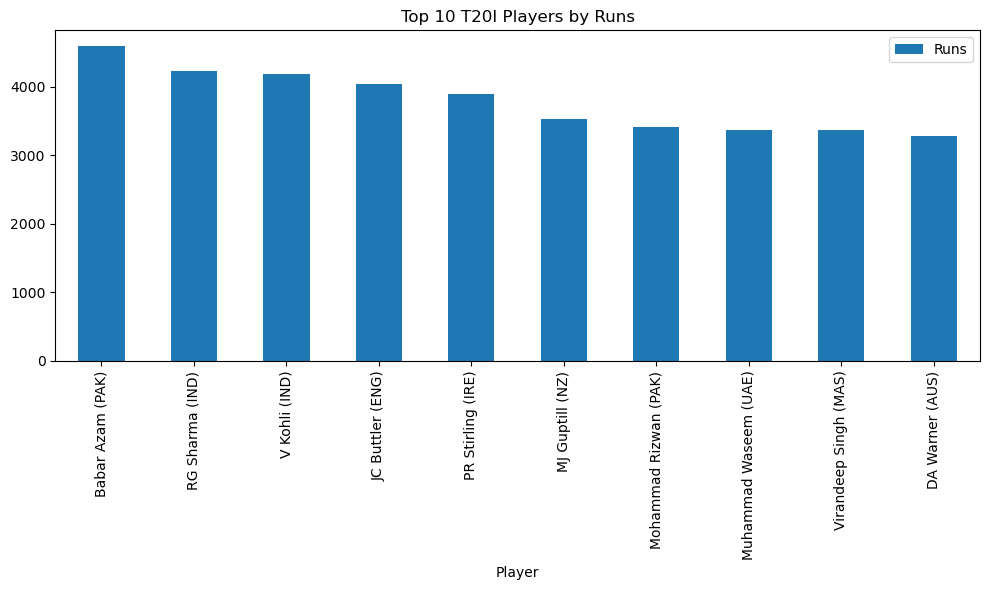

In [11]:
# Visualization: Top 10 Players by Runs
top_players.plot(x='Player', y='Runs', kind='bar')
plt.title('Top 10 T20I Players by Runs')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 6. Power Hitters (Strike Rate)

In [12]:
# Best Power Hitters (Strike Rate)
power_hitters = df.sort_values('SR', ascending=False)[['Player', 'SR']].head(10)
power_hitters


,Player,SR
112,Abhishek Sharma (IND),192.83
401,Musaddiq Ahmed (GER),181.72
429,KJ Stagno (GIBR),177.29
25,Karanbir Singh (AUT),175.41
299,Mohammad Ihsan (ESP),174.58
88,Faisal Khan (KSA),173.43
100,FH Allen (NZ),170.73
201,Saber Zakhil (BEL),169.04
95,TH David (AUS/SGP),168.40
154,Adil Butt (SWZ),166.25


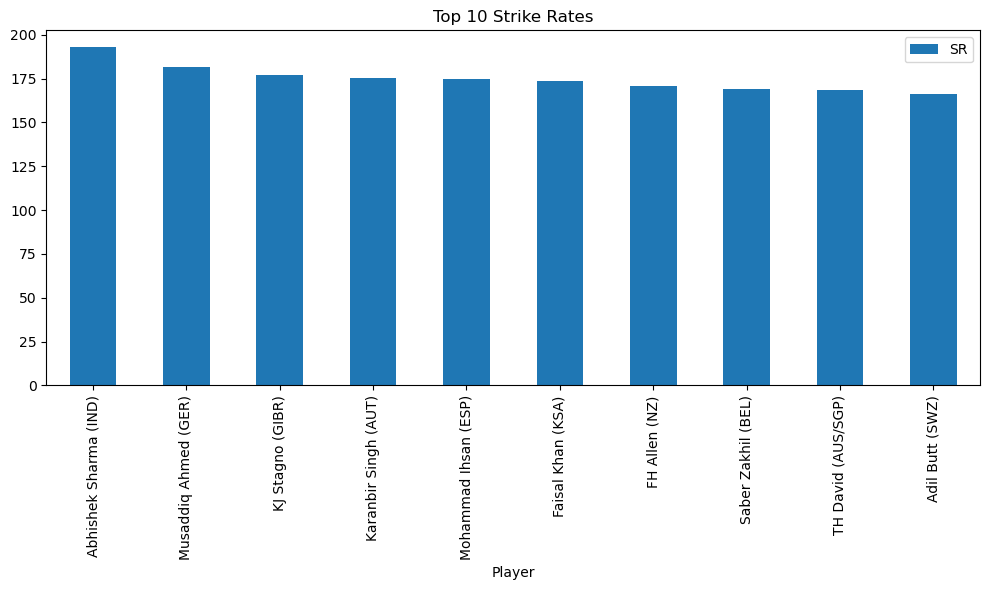

In [13]:
power_hitters.plot(x='Player', y='SR', kind='bar')
plt.title('Top 10 Strike Rates')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 7. Most Consistent Players (Average)

In [14]:
consistent = df.sort_values('Ave', ascending=False)[['Player', 'Ave']].head(10)
consistent


,Player,Ave
332,Luka Woods (SRB),53.33
25,Karanbir Singh (AUT),48.71
2,V Kohli (IND),48.69
6,Mohammad Rizwan (PAK),47.41
300,D Visser (Samoa),46.94
299,Mohammad Ihsan (ESP),46.94
51,Sami Sohail (MWI),45.76
392,MK Pandey (IND),44.31
120,NT Tilak Varma (IND),44.14
233,J Baker (CAY),42.95


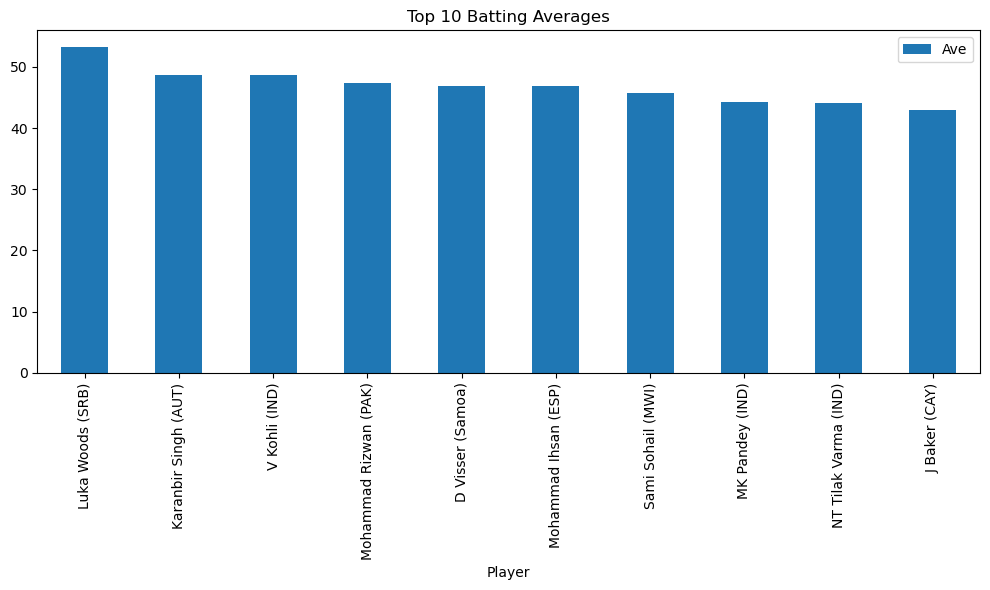

In [15]:
consistent.plot(x='Player', y='Ave', kind='bar')
plt.title('Top 10 Batting Averages')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 8. Correlation Analysis

In [16]:
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()
correlation


,Mat,Inns,NO,Runs,Ave,BF,SR,100,50,0,4s,6s,Unnamed: 15
Mat,1.000000,0.966498,0.702994,0.748752,-0.105612,0.767476,0.024985,0.126107,0.489541,0.574543,0.639623,0.606461,NaN
Inns,0.966498,1.000000,0.599638,0.852552,-0.025199,0.871940,0.041868,0.195201,0.615698,0.594049,0.763684,0.677591,NaN
NO,0.702994,0.599638,1.000000,0.384259,0.091602,0.385734,0.048712,-0.047368,0.160567,0.219538,0.215326,0.335564,NaN
Runs,0.748752,0.852552,0.384259,1.000000,0.405711,0.970157,0.248454,0.449449,0.899275,0.377766,0.950731,0.816721,NaN
Ave,-0.105612,-0.025199,0.091602,0.405711,1.000000,0.313030,0.480745,0.460821,0.530262,-0.321641,0.397335,0.387353,NaN
BF,0.767476,0.871940,0.385734,0.970157,0.313030,1.000000,0.026844,0.341680,0.858532,0.394644,0.929074,0.694782,NaN
SR,0.024985,0.041868,0.048712,0.248454,0.480745,0.026844,1.000000,0.451410,0.266437,-0.019703,0.217171,0.549173,NaN
100,0.126107,0.195201,-0.047368,0.449449,0.460821,0.341680,0.451410,1.000000,0.424649,0.097430,0.457231,0.543995,NaN
50,0.489541,0.615698,0.160567,0.899275,0.530262,0.858532,0.266437,0.424649,1.000000,0.248423,0.893579,0.719296,NaN
0,0.574543,0.594049,0.219538,0.377766,-0.321641,0.394644,-0.019703,0.097430,0.248423,1.000000,0.360809,0.333208,NaN


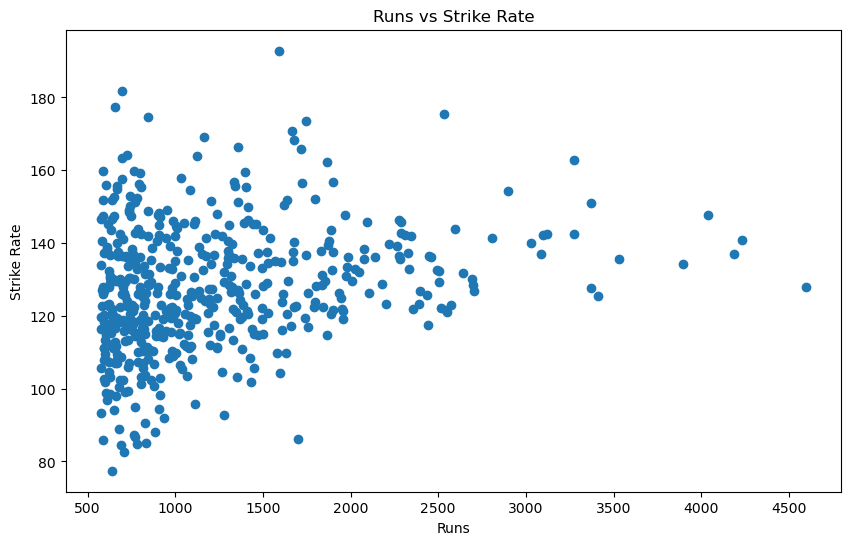

In [17]:
# Visualization: Runs vs Strike Rate
plt.scatter(df['Runs'], df['SR'])
plt.xlabel('Runs')
plt.ylabel('Strike Rate')
plt.title('Runs vs Strike Rate')
plt.show()


## 9. Player Role Analysis

In [18]:
# Anchor Players: high average AND high strike rate
anchors = df[(df['Ave'] > 40) & (df['SR'] > 130)]
anchors[['Player', 'Ave', 'SR']].head(10)


,Player,Ave,SR
2,V Kohli (IND),48.69,137.04
25,Karanbir Singh (AUT),48.71,175.41
120,NT Tilak Varma (IND),44.14,143.49
152,DMW Rawlins (BER),41.18,151.16
154,Adil Butt (SWZ),41.06,166.25
233,J Baker (CAY),42.95,131.00
250,Faheem Nazir (SUI),42.82,145.92
299,Mohammad Ihsan (ESP),46.94,174.58
300,D Visser (Samoa),46.94,142.01
332,Luka Woods (SRB),53.33,159.36


In [19]:
# Finisher Players: very high strike rate
finishers = df[df['SR'] > 150]
finishers[['Player', 'Runs', 'SR']].head(10)


,Player,Runs,SR
7,Muhammad Waseem (UAE),3371,150.96
10,SA Yadav (IND),3272,162.94
15,GJ Maxwell (AUS),2897,154.42
25,Karanbir Singh (AUT),2533,175.41
67,TP Ura (PNG),1900,156.89
76,Bilal Zalmai (AUT),1864,162.22
83,E Lewis (WI),1799,152.07
88,Faisal Khan (KSA),1743,173.43
91,C Munro (NZ),1724,156.44
92,PD Salt (ENG),1717,165.73


## 10. Additional Visualizations

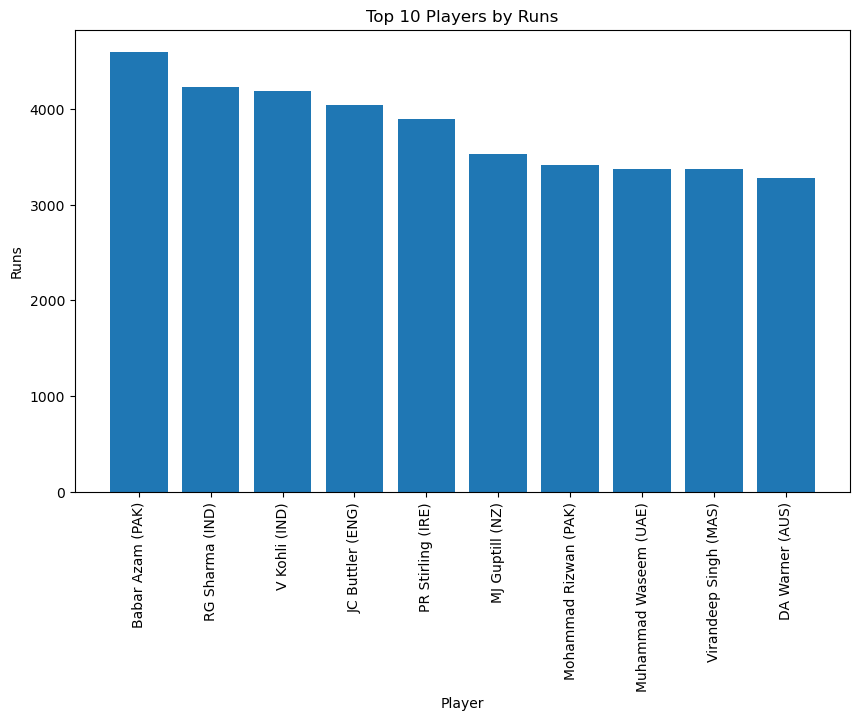

In [20]:
# Top 10 Players by Runs
top_runs = df.sort_values(by='Runs', ascending=False).head(10)

plt.figure()
plt.bar(top_runs['Player'], top_runs['Runs'])
plt.xticks(rotation=90)
plt.title('Top 10 Players by Runs')
plt.xlabel('Player')
plt.ylabel('Runs')
plt.show()


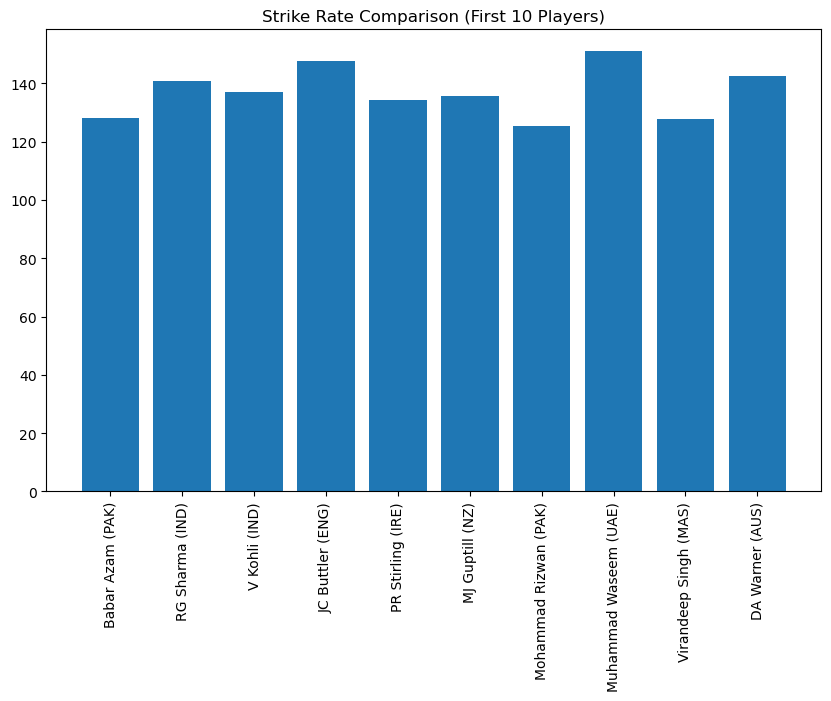

In [21]:
# Strike Rate Comparison (first 10 players in dataset order)
top10_sample = df.head(10)
plt.figure()
plt.bar(top10_sample['Player'], top10_sample['SR'])
plt.xticks(rotation=90)
plt.title('Strike Rate Comparison (First 10 Players)')
plt.show()


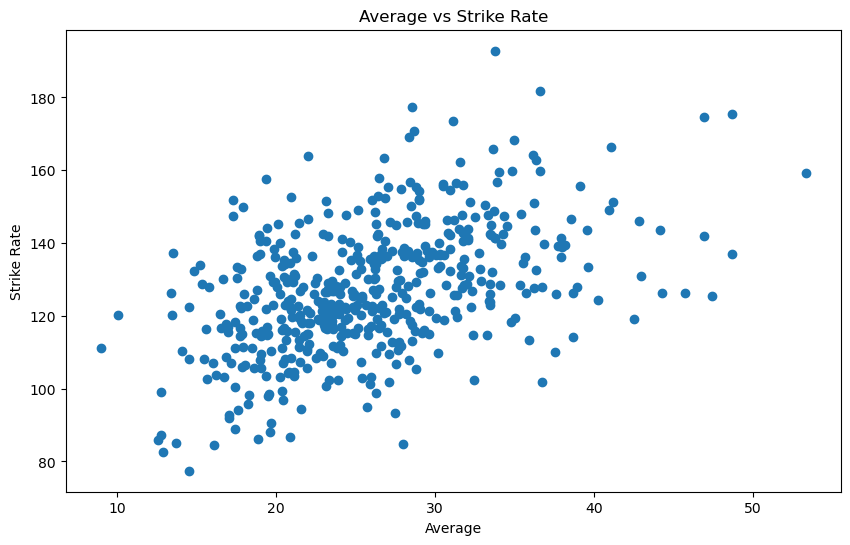

In [22]:
# Average vs Strike Rate (Scatter)
plt.figure()
plt.scatter(df['Ave'], df['SR'])
plt.title('Average vs Strike Rate')
plt.xlabel('Average')
plt.ylabel('Strike Rate')
plt.show()


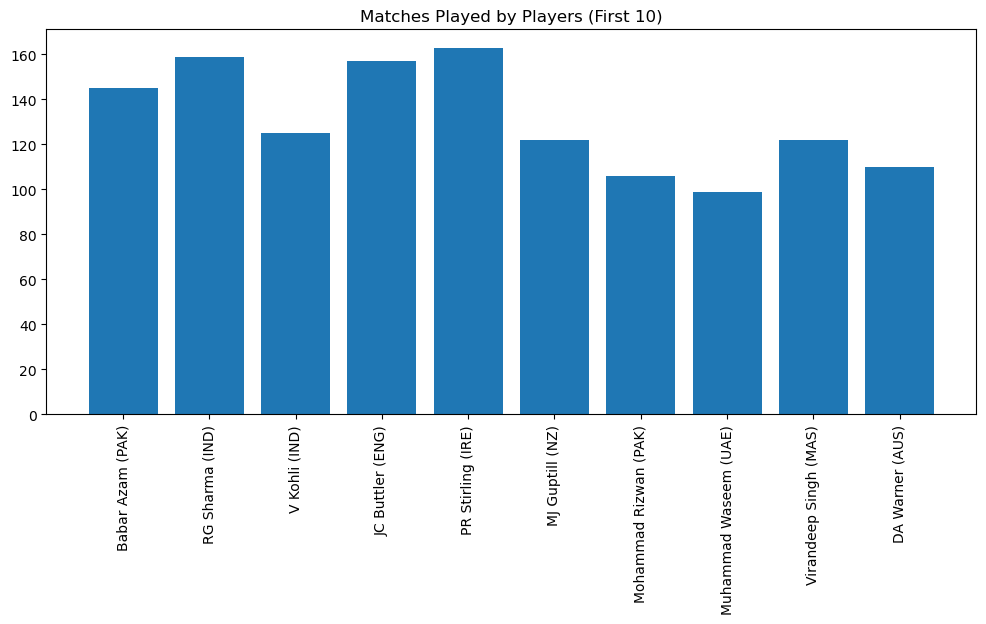

In [23]:
# Matches Played (first 10 players in dataset order)
top10_sample_matches = df.head(10)
plt.figure(figsize=(12, 5))
plt.bar(top10_sample_matches['Player'], top10_sample_matches['Mat'])
plt.xticks(rotation=90)
plt.title('Matches Played by Players (First 10)')
plt.show()


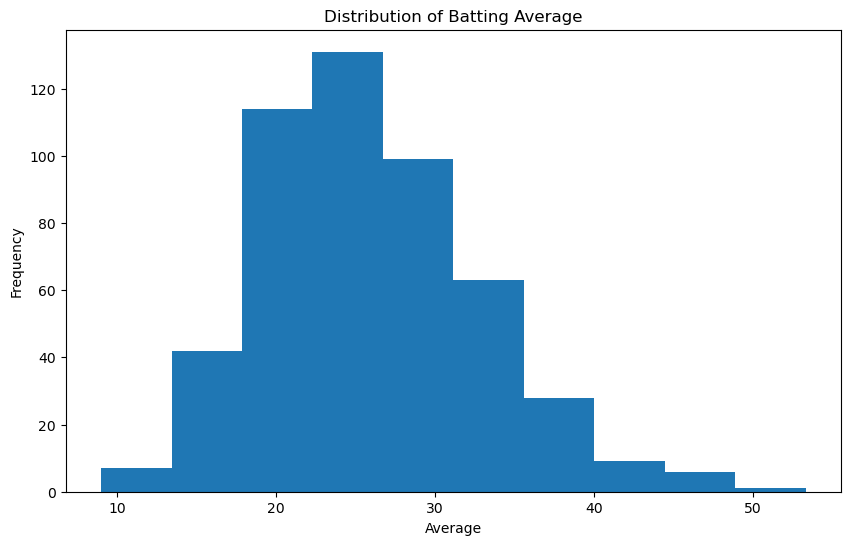

In [24]:
# Distribution of Average
plt.figure()
plt.hist(df['Ave'], bins=10)
plt.title('Distribution of Batting Average')
plt.xlabel('Average')
plt.ylabel('Frequency')
plt.show()


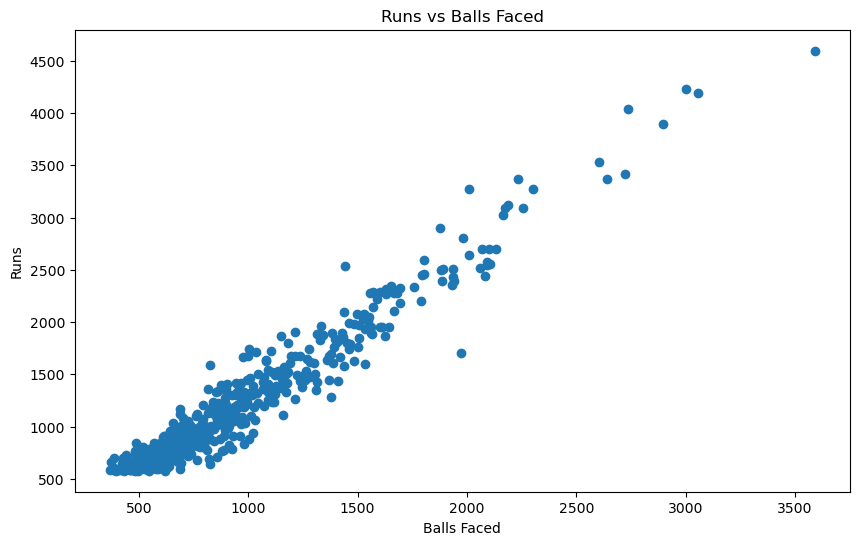

In [25]:
# Runs vs Balls Faced
plt.figure()
plt.scatter(df['BF'], df['Runs'])
plt.title('Runs vs Balls Faced')
plt.xlabel('Balls Faced')
plt.ylabel('Runs')
plt.show()


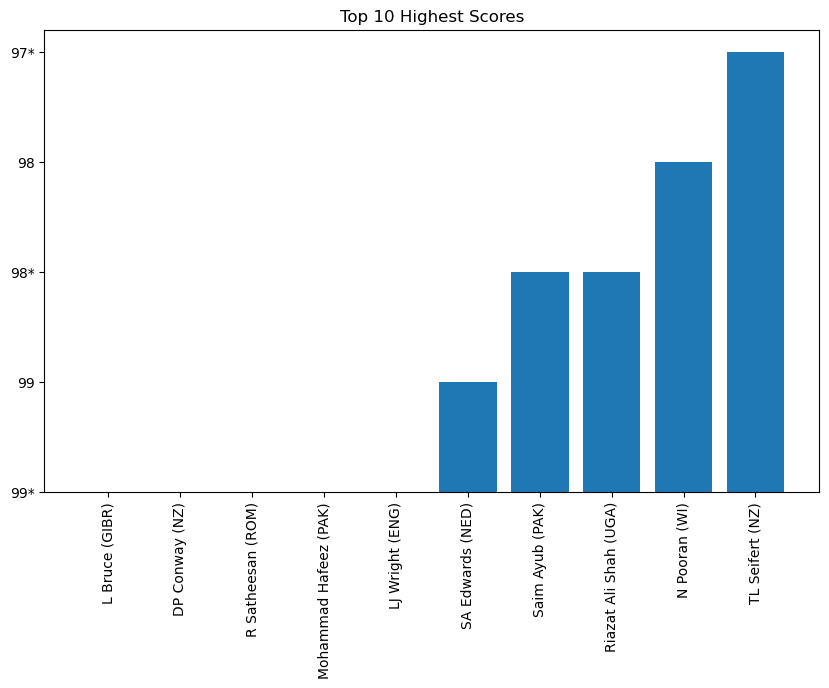

In [26]:
# Top 10 Highest Scores
top_score = df.sort_values(by='HS', ascending=False).head(10)

plt.figure()
plt.bar(top_score['Player'], top_score['HS'])
plt.xticks(rotation=90)
plt.title('Top 10 Highest Scores')
plt.show()


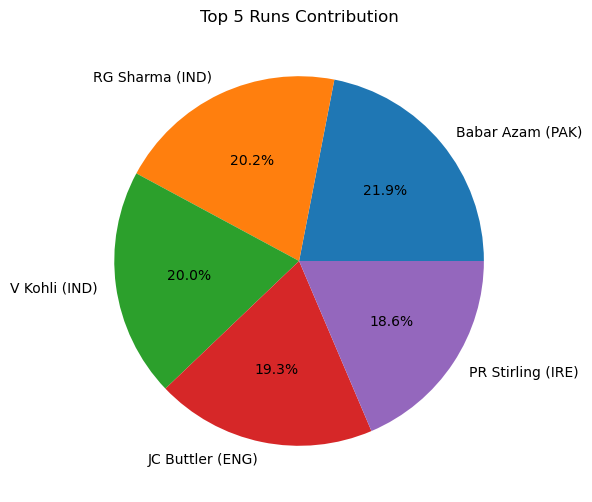

In [27]:
# Pie Chart (Runs Contribution)
top5 = df.sort_values(by='Runs', ascending=False).head(5)

plt.figure()
plt.pie(top5['Runs'], labels=top5['Player'], autopct='%1.1f%%')
plt.title('Top 5 Runs Contribution')
plt.show()


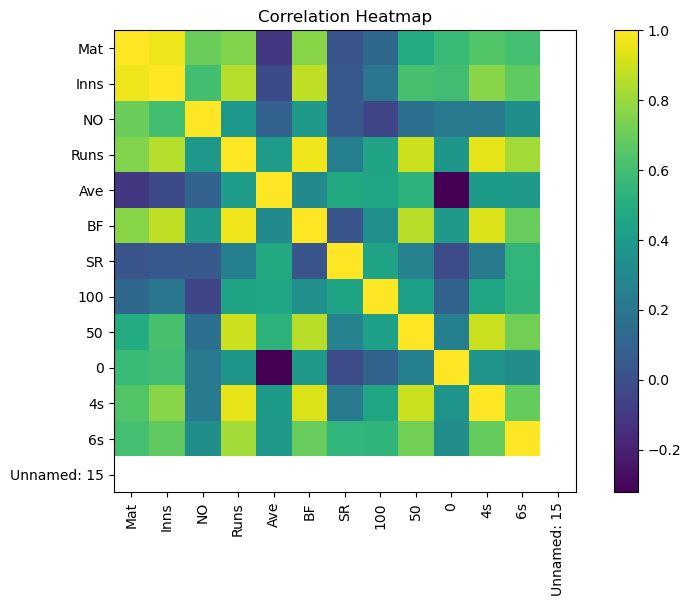

In [28]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()


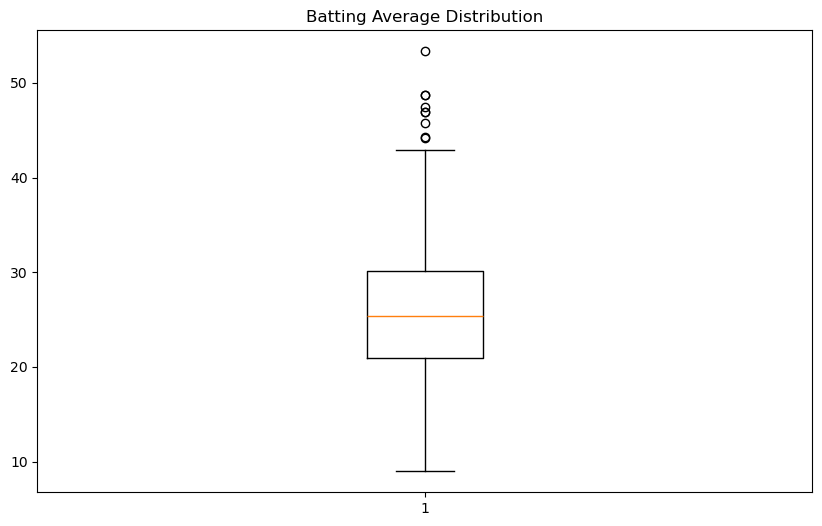

In [29]:
# Box Plot (Check Consistency)
plt.figure()
plt.boxplot(df['Ave'])
plt.title('Batting Average Distribution')
plt.show()


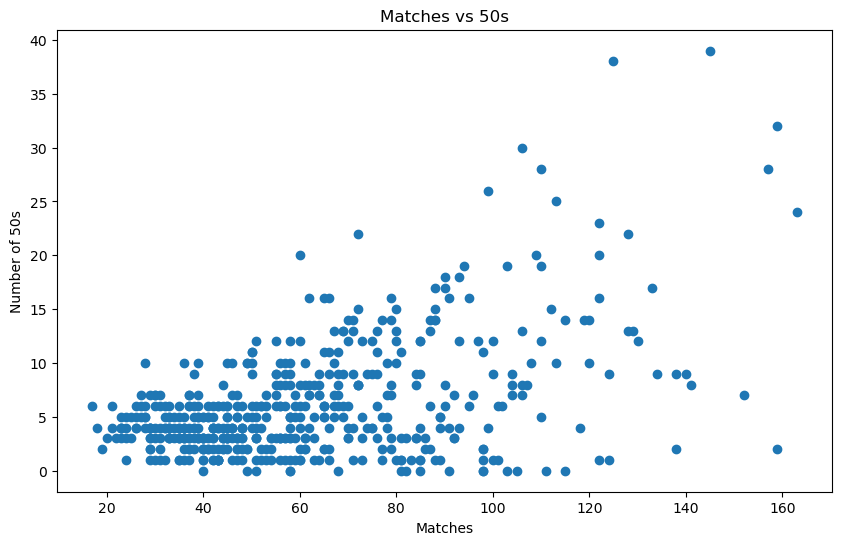

In [30]:
# Matches vs 50s
plt.figure()
plt.scatter(df['Mat'], df['50'])
plt.title('Matches vs 50s')
plt.xlabel('Matches')
plt.ylabel('Number of 50s')
plt.show()


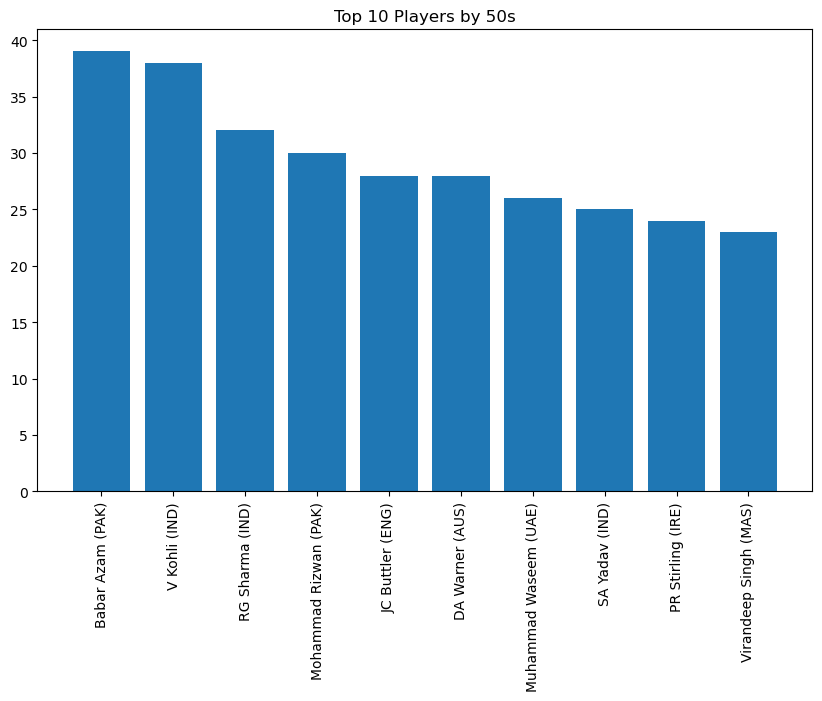

In [31]:
# Most 50s by top 10 players
top_50s = df.sort_values(by='50', ascending=False).head(10)

plt.figure()
plt.bar(top_50s['Player'], top_50s['50'])
plt.xticks(rotation=90)
plt.title('Top 10 Players by 50s')
plt.show()


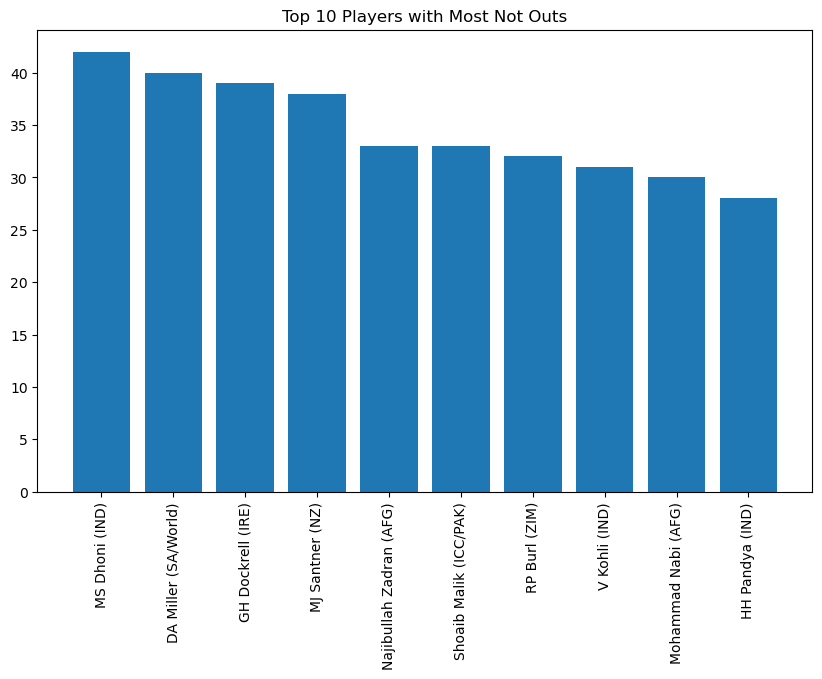

In [32]:
# Top 10 Players with Most Not Outs
top_no = df.sort_values(by='NO', ascending=False).head(10)

plt.figure()
plt.bar(top_no['Player'], top_no['NO'])
plt.xticks(rotation=90)
plt.title('Top 10 Players with Most Not Outs')
plt.show()


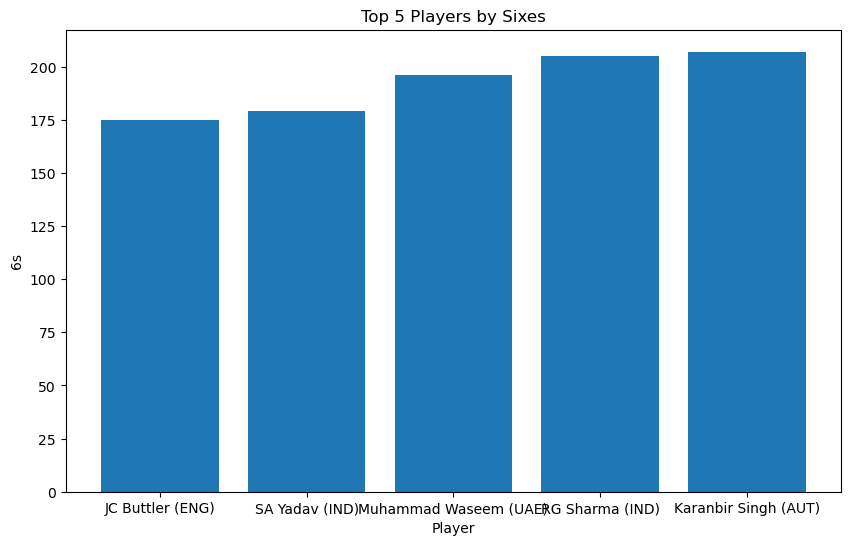

In [33]:
# Top 5 Players with highest 6s hitting
top6 = df.sort_values(by='6s', ascending=True).tail(5)

plt.figure()
plt.bar(top6['Player'], top6['6s'])
plt.title('Top 5 Players by Sixes')
plt.xlabel('Player')
plt.ylabel('6s')
plt.show()


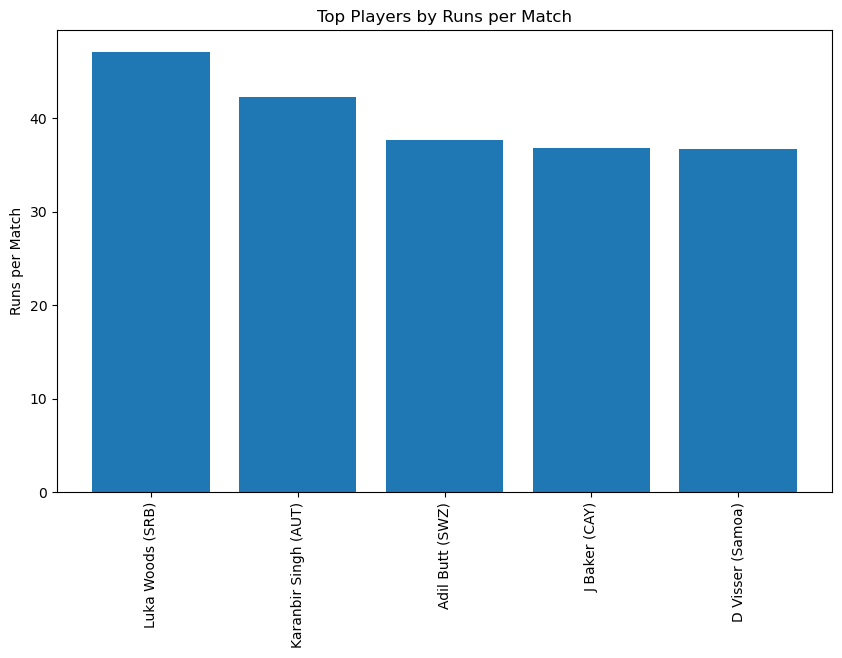

In [34]:
# Runs per Match (Efficiency)
df['Runs_per_match'] = df['Runs'] / df['Mat']

top_eff = df.sort_values(by='Runs_per_match', ascending=False).head(5)

plt.figure()
plt.bar(top_eff['Player'], top_eff['Runs_per_match'])
plt.xticks(rotation=90)
plt.title('Top Players by Runs per Match')
plt.ylabel('Runs per Match')
plt.show()


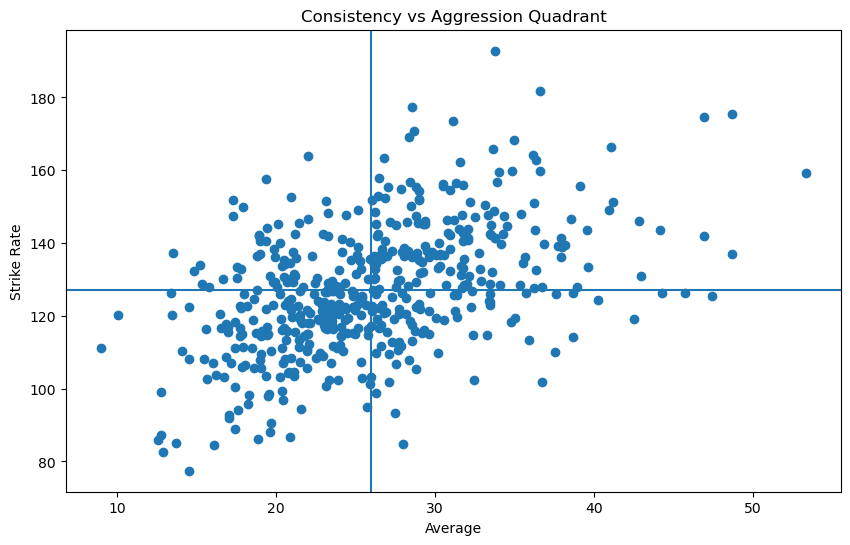

In [35]:
# Consistency vs Aggression
plt.figure()
plt.scatter(df['Ave'], df['SR'])
plt.axhline(y=df['SR'].mean())
plt.axvline(x=df['Ave'].mean())
plt.title('Consistency vs Aggression Quadrant')
plt.xlabel('Average')
plt.ylabel('Strike Rate')
plt.show()


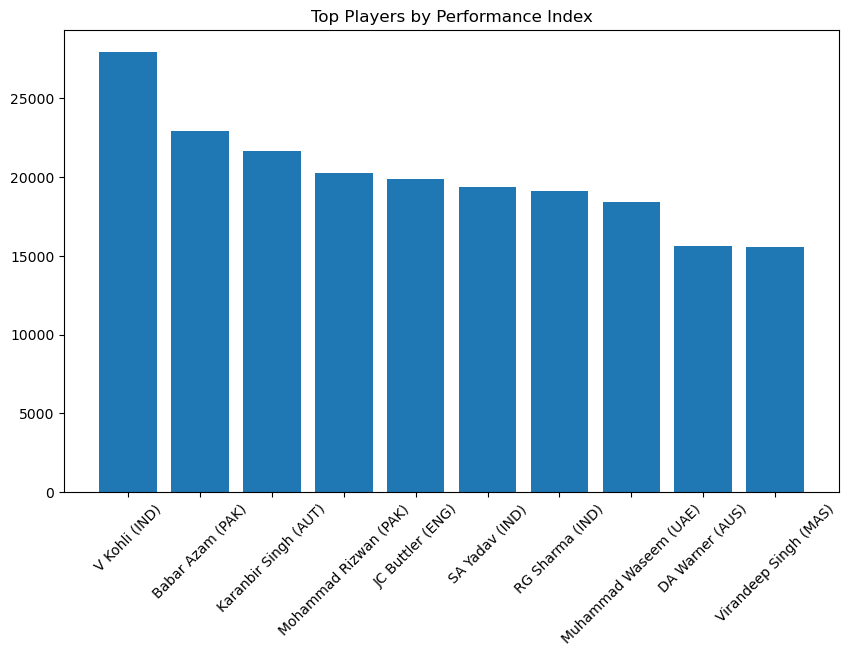

In [36]:
# Top players by Performance Index
df['Performance_Index'] = (df['Runs'] * df['Ave'] * df['SR']) / 1000

top_perf = df.sort_values(by='Performance_Index', ascending=False).head(10)

plt.figure()
plt.bar(top_perf['Player'], top_perf['Performance_Index'])
plt.xticks(rotation=45)
plt.title('Top Players by Performance Index')
plt.show()
